In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


In [2]:
import joblib
path = '..\\data\\meteo_data_clipped.pkl'
meteo_data = joblib.load(path)

In [3]:
dictio = pd.read_csv("..\\data\\variables_description.csv")
dictio.index = dictio['variable']
#dictio

In [ ]:
df = meteo_data['df']
df = df[df['time_to_next_cg20'].notna()]
VAR = meteo_data['VAR']
dummies_vars = meteo_data['dumies_vars']
selected_features = meteo_data['df']
IDS = meteo_data['IDS']
TARGET = meteo_data['TARGET']

In [5]:
df['time_to_next_cg20'].quantile([0.84, 0.85, 0.86, 0.87, 0.88, 0.89,0.90,0.95,0.99])


0.84        726.00
0.85        837.00
0.86        976.00
0.87       1149.00
0.88       1379.00
0.89       1686.00
0.90       2113.00
0.95      41126.40
0.99    1075467.92
Name: time_to_next_cg20, dtype: float64

In [6]:
df['time_to_next_cg20'].describe()

count    5.070290e+05
mean     3.628409e+04
std      2.779005e+05
min      0.000000e+00
25%      1.100000e+01
50%      4.700000e+01
75%      2.650000e+02
max      1.972700e+07
Name: time_to_next_cg20, dtype: float64

In [7]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_10min_cg20'] = df['time_to_next_cg20'] > (10 * 60) # LE prochain arrive dans moins de 10 minutes


In [8]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_30min_cg20'] = df['time_to_next_cg20'] > (30 * 60) # LE prochain arrive dans moins de 10 minutes
df['next_30min_cg20'].value_counts()

next_30min_cg20
False    452783
True      54246
Name: count, dtype: int64

In [9]:
df.groupby("season")["next_30min_cg20"].mean()

season
Automne      0.090083
Hiver        0.275135
Printemps    0.161687
Été          0.098538
Name: next_30min_cg20, dtype: float64

## Séparation en train, test et OOT

Le developpement du score se fera sur une période : entre **2019--2021** et **2022** la validation hors temps




In [10]:
from sklearn.model_selection import train_test_split
target_col = 'next_30min_cg20'
data = df
# Combine the two columns for stratification
dev_mask = (df['year'] >= 2015) & (df['year'] <= 2021)
stratify_col = (data[target_col].astype(str)+ "_" + data['airport'] + "_" + data['month'].astype(str))[dev_mask]
train_data, test_data = train_test_split(
	data[dev_mask], 
	test_size=0.2, 
	random_state=42, 
	stratify=stratify_col
)
train_data, test_data = train_data.reset_index(drop=True), test_data.reset_index(drop=True)
oot_data = data[data['year'] >= 2022].reset_index(drop=True)
train_data.shape, test_data.shape, oot_data.shape

((343496, 110), (85874, 110), (77659, 110))

In [11]:
X_train = train_data[VAR+["airport",'season']].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[VAR+["airport",'season']].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[VAR+["airport",'season']].copy()
y_oot = oot_data[target_col].copy()*1

# IMPUTATION

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit sur train uniquement
X_train[VAR] = imputer.fit_transform(X_train[VAR])

# Transform sur test et OOT avec les médianes du train
X_test[VAR] = imputer.transform(X_test[VAR])
X_oot[VAR]  = imputer.transform(X_oot[VAR])

print("Médianes utilisées :")
print(dict(zip(VAR+["airport",'season'], imputer.statistics_)))


Médianes utilisées :
{'min_dist_5min': np.float64(6.311859706245813), 'time_since_last_CG20_2': np.float64(3.828641396489095), 'log_count_30min': np.float64(5.720311776607412), 'amplitude_change': np.float64(0.04314933328679471), 'activity_decay': np.float64(1.0531400457420268), 'time_since_last_intra_cloud2': np.float64(1.6094379124341003), 'log_cg_count_10min': np.float64(3.1780538303479458), 'min_dist_1min': np.float64(10.588223419718522), 'cg_20km': np.float64(0.0), 'log_std_amplitude_10min': np.float64(2.338981182610136), 'is_cloud_ground': np.float64(0.0), 'log_cg_count_20min': np.float64(3.7612001156935624), 'burst_indicator': np.float64(1.0), 'hour': np.float64(13.0), 'storm_direction_change': np.float64(3.0237074501151575), 'time_since_last_cloud_ground2': np.float64(2.833213344056216), 'std_lat_10min': np.float64(0.0746883975020784), 'mean_dist_1min': np.float64(20.57058976638803), 'dist': np.float64(21.347240670454507), 'log_count_5min': np.float64(4.174387269895637), 'alert

# Un premier score benchmark

In [13]:
top_var = ['min_dist_10min', 'min_dist_1min', 'log_cg_count_10min', 'log_cg_count_5min', 'log_count_5min', 'log_count_10min', 'log_cg_count_20min', 'std_azimuth_1min', 'mean_dist_5min', 'log_count_20min', 'std_azimuth_10min', 'rate_trend', 'mean_dist_1min', 'log_count_1min', 'storm_spread', 'log_count_30min', 'mean_dist_10min', 'log_ic_count_5min', 'log_ic_count_10min', 'log_ic_count_20min', 'std_lon_10min', 'std_lat_10min', 'time_since_last_lightning2', 'burst_indicator', 'time_since_last_cloud_ground2', 'activity_decay', 'max_amplitude_10min', 'dist', 'max_amplitude_1min', 'mean_azimuth_1min', 'mean_azimuth_10min', 'storm_direction_change', 'distance_trend', 'season', 'cg_20km', 'alert_duration', 'azimuth', 'azimuth_change']
len(top_var)

38

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_vars = top_var
#  = ['log_cg_count_5min', 'log_count_5min', 'log_cg_count_10min',
#        'mean_dist_5min', 'cg_20km', 'min_dist_1min', 'log_count_1min',
#        'min_dist_5min', 'log_ic_count_5min', 'mean_dist_10min',
#        'mean_dist_1min', 'hour', 'log_cg_count_20min', 'storm_spread',
#        'min_dist_10min', 'mean_azimuth_10min', 'log_count_30min',
#        'mean_azimuth_1min', 'time_since_last_lightning2',
#        'storm_center_distance']#VAR+["airport",'season'] 

X_train = train_data[xgb_vars].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[xgb_vars].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[xgb_vars].copy()
y_oot = oot_data[target_col].copy()*1
combined = pd.concat([X_train, X_test,X_oot], keys=['train', 'test','oot'])
combined_enc = pd.get_dummies(combined)

#Séparer avec les mêmes colonnes
X_train_enc = combined_enc.xs('train')#
X_test_enc = combined_enc.xs('test')
X_oot_enc = combined_enc.xs('oot')



In [15]:
# import optuna
# from xgboost import XGBClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# def objective(trial):
#     params = {
#         "objective":        "binary:logistic",
#         "eval_metric":      "auc",
#         "tree_method":      "hist",
#         "random_state":     42,
#         "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
#         "max_depth":        trial.suggest_int("max_depth", 3, 8),
#         "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "gamma":            trial.suggest_float("gamma", 0, 15),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
#         "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
#         "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
#     }

#     model = XGBClassifier(**params,eval_set=[(X_test_enc, y_test)])
#     scores = cross_val_score(model, X_train_enc, y_train,
#                              cv=cv, scoring="roc_auc", n_jobs=-1)
#     return scores.mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print(f"Meilleur AUC CV : {study.best_value:.4f}")
# print("Meilleurs paramètres :")
# study.best_params


In [18]:
params = {'n_estimators': 791,
 'max_depth': 7,
 'learning_rate': 0.18953249251578172,
 'subsample': 0.6894952927400104,
 'colsample_bytree': 0.9942012325748735,
 'gamma': 0.20551203959759956,
 'min_child_weight': 12,
 'reg_alpha': 0.5201158139444992,
 'reg_lambda': 1.2240878901657437}

model_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    **params
)
model_xgb.fit(X_train_enc, y_train, eval_set=[(X_test_enc, y_test)], verbose=False)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9942012325748735
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [19]:
from sklearn.metrics import average_precision_score
y_pred = model_xgb.predict(X_oot_enc)
print(classification_report(y_oot, y_pred))

proba_train = model_xgb.predict_proba(X_train_enc)[:, 1]
proba_test  = model_xgb.predict_proba(X_test_enc)[:, 1]
proba_oot  = model_xgb.predict_proba(X_oot_enc)[:, 1]

prevalence = y_test.mean()

auc_train   = roc_auc_score(y_train, proba_train)
gini_train  = 2 * auc_train - 1

auc_test    = roc_auc_score(y_test, proba_test)
auc_pr_test = average_precision_score(y_test, proba_test)
rp          = auc_pr_test / prevalence
gini_test  = 2 * auc_test - 1

auc_oot    = roc_auc_score(y_oot, proba_oot)
auc_pr_oot = average_precision_score(y_oot, proba_oot)
rp_o          = auc_pr_oot / y_oot.mean()
gini_oot  = 2 * auc_oot - 1
print(f"ROC AUC TRAIN: {auc_train:.4f}  |  Gini TRAIN: {gini_train:.4f}")
print(f"ROC AUC TEST:  {auc_test:.4f} |  Gini Test: {gini_test:.4f}")
print(f"PR AUC TEST:   {auc_pr_test:.4f}  |  Ratio RP: {rp:.4f}")
print(f"ROC AUC OOT:  {auc_oot:.4f} |  Gini OOT: {gini_oot:.4f}")
print(f"PR AUC OOT:   {auc_pr_oot:.4f}  |  Ratio RP OOT: {rp_o:.4f}")


              precision    recall  f1-score   support

           0       0.93      0.96      0.95     69228
           1       0.58      0.44      0.50      8431

    accuracy                           0.90     77659
   macro avg       0.76      0.70      0.72     77659
weighted avg       0.90      0.90      0.90     77659

ROC AUC TRAIN: 0.9998  |  Gini TRAIN: 0.9995
ROC AUC TEST:  0.9896 |  Gini Test: 0.9792
PR AUC TEST:   0.9164  |  Ratio RP: 8.5880
ROC AUC OOT:  0.9117 |  Gini OOT: 0.8233
PR AUC OOT:   0.5303  |  Ratio RP OOT: 4.8843


In [20]:
test_data['probas'] = proba_test
train_data['probas'] = proba_train
oot_data['probas'] = proba_oot
test_data['points'] = proba_test*1000
train_data['points'] = proba_train*1000
oot_data['points'] = proba_oot*1000

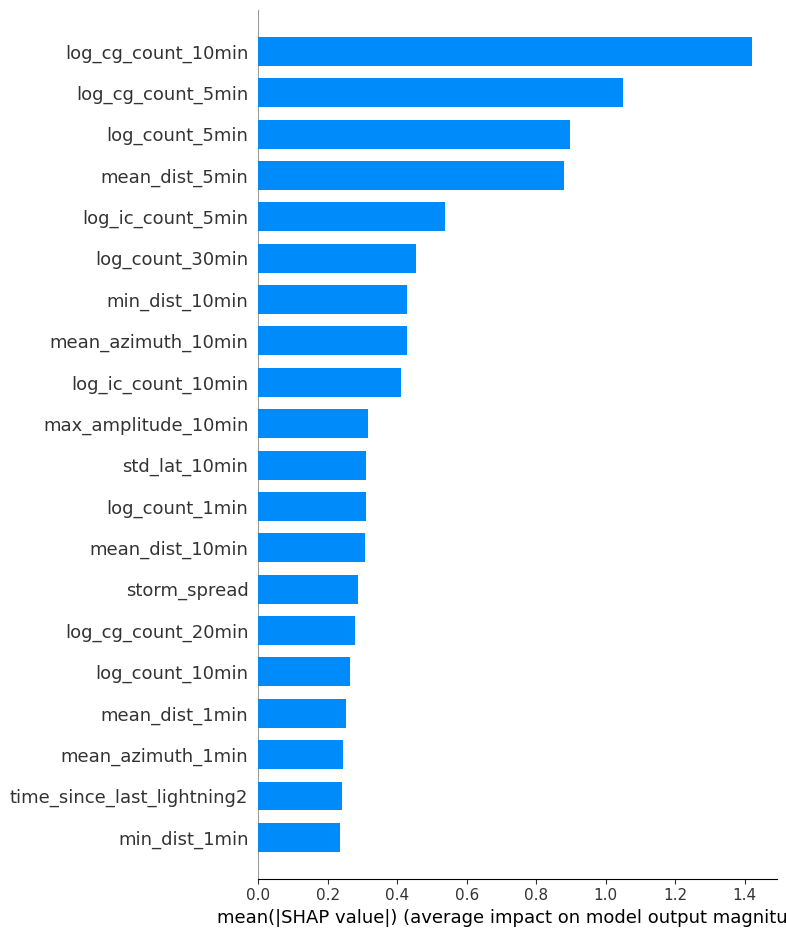

In [20]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_train_enc)

shp = shap.summary_plot(shap_values, X_train_enc, plot_type="bar")


In [21]:
# Importance = moyenne des |valeurs SHAP|
importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_train_enc.columns
).sort_values(ascending=False)

print(importance.to_string())

log_cg_count_10min               1.421756
log_cg_count_5min                1.050364
log_count_5min                   0.898596
mean_dist_5min                   0.878850
log_ic_count_5min                0.538637
log_count_30min                  0.453604
min_dist_10min                   0.429243
mean_azimuth_10min               0.428210
log_ic_count_10min               0.411986
max_amplitude_10min              0.317576
std_lat_10min                    0.309782
log_count_1min                   0.309534
mean_dist_10min                  0.306410
storm_spread                     0.288134
log_cg_count_20min               0.277884
log_count_10min                  0.263043
mean_dist_1min                   0.251802
mean_azimuth_1min                0.244398
time_since_last_lightning2       0.241096
min_dist_1min                    0.235467
std_lon_10min                    0.234575
std_azimuth_10min                0.223580
max_amplitude_1min               0.185551
std_azimuth_1min                 0

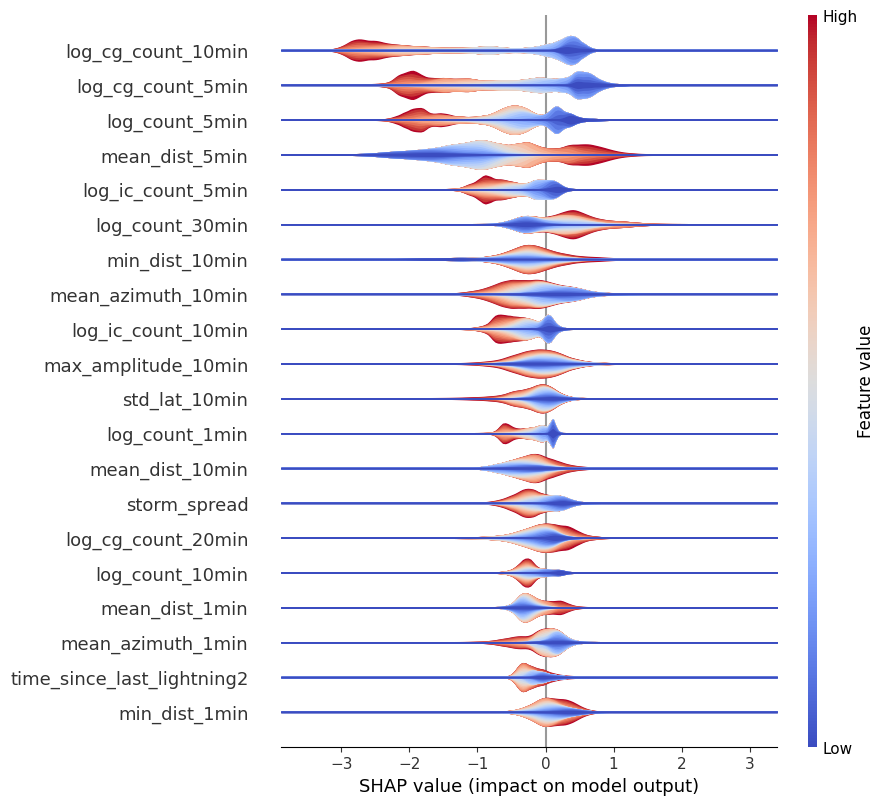

In [22]:
feat_names = X_train_enc.columns.tolist()
shap.plots.violin(
    shap_values,
    features=X_train_enc,
    feature_names=feat_names,
    plot_type="layered_violin",
    max_display=20  # Limite à 20 variables les plus importantes
)

# Analyse des performances

## AUC maské

In [22]:
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_on_mask(df, mask, y_col, proba_col):
    """
    Calcule GINI, ROC AUC et Ratio RP (PR AUC / prevalence) sur un sous-ensemble du DataFrame.

    Paramètres
    ----------
    df        : DataFrame complet
    mask      : condition booléenne, ex: df['airport'] == 'PAU'
    y_col     : nom de la colonne cible (0/1)
    proba_col : nom de la colonne de probabilités prédites

    Retourne
    --------
    dict avec les métriques
    """
    subset = df[mask]

    if len(subset) == 0:
        print("Masque vide — aucune ligne ne vérifie la condition.")
        return None

    y     = subset[y_col]
    proba = subset[proba_col]

    if y.nunique() < 2:
        print(f"Une seule classe présente dans le sous-ensemble ({len(subset)} lignes) — AUC indéfinie.")
        return None

    prevalence  = y.mean()
    auc         = roc_auc_score(y, proba)
    gini        = 2 * auc - 1
    auc_pr      = average_precision_score(y, proba)
    rp          = auc_pr / prevalence

    # print(f"Sous-ensemble : {len(subset)} lignes  |  Prevalence : {prevalence:.3%}")
    # print(f"ROC AUC : {auc:.4f}  |  Gini : {gini:.4f}")
    # print(f"PR AUC  : {auc_pr:.4f}  |  Ratio RP : {rp:.4f}")

    return {"n": len(subset), "prevalence": prevalence,
            "auc": auc, "gini": gini, "auc_pr": auc_pr, "rp": rp}


### par aeroport

In [23]:
def auc_mask(train_data,col = "airport"):
    results = []
    for airport in train_data[col].unique():
        mask = train_data[col] == airport
        metrics = eval_on_mask(train_data, mask=mask, y_col=target_col, proba_col='probas')
        if metrics:
            metrics[col] = airport
            results.append(metrics)

    df_results = (pd.DataFrame(results)
                    .set_index(col)
                    [['n', 'prevalence', 'auc', 'gini', 'auc_pr', 'rp']]
                    .sort_values('rp', ascending=False))
    return df_results
    # df_results.style.format({
    #     'prevalence': '{:.2%}',
    #     'auc':        '{:.4f}',
    #     'gini':       '{:.4f}',
    #     'auc_pr':     '{:.4f}',
    #     'rp':         '{:.2f}',
    # }).background_gradient(subset=['auc', 'gini', 'rp'], cmap='RdYlGn')


In [24]:
auc_mask(train_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Nantes,23313,0.095655,0.999730,0.999459,0.997317,10.426213
Bastia,90373,0.095725,0.999790,0.999580,0.997933,10.424948
Biarritz,76681,0.106676,0.999812,0.999625,0.998352,9.358757
Pise,108147,0.114224,0.999804,0.999607,0.998418,8.740863
Ajaccio,44982,0.116447,0.999391,0.998782,0.995049,8.545110


In [25]:
auc_mask(test_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,22593,0.095738,0.992127,0.984255,0.927140,9.684178
Nantes,5828,0.095573,0.987198,0.974396,0.876793,9.174053
Biarritz,19174,0.106759,0.991587,0.983174,0.932780,8.737238
Pise,27038,0.114247,0.990277,0.980555,0.926740,8.111746
Ajaccio,11241,0.116271,0.978834,0.957668,0.853363,7.339441


In [26]:
auc_mask(oot_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Biarritz,19320,0.083747,0.937701,0.875402,0.539542,6.442487
Ajaccio,16276,0.082576,0.936150,0.872301,0.507738,6.148764
Nantes,7586,0.122594,0.912459,0.824919,0.546116,4.454660
Pise,21527,0.116273,0.890719,0.781437,0.499647,4.297206
Bastia,12950,0.157220,0.902868,0.805735,0.596886,3.796501


### par saison

In [27]:
auc_mask(train_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,110795,0.086349,0.999723,0.999447,0.996803,11.543932
Été,190479,0.095113,0.999861,0.999721,0.998645,10.499580
Printemps,33814,0.193381,0.999439,0.998877,0.997560,5.158509
Hiver,8408,0.288892,0.998076,0.996153,0.994822,3.443584


In [28]:
auc_mask(test_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,27699,0.086357,0.988917,0.977833,0.894067,10.353160
Été,47619,0.095130,0.993928,0.987857,0.943346,9.916381
Printemps,8451,0.193113,0.972908,0.945815,0.886336,4.589719
Hiver,2105,0.289311,0.931557,0.863114,0.834290,2.883711


In [29]:
auc_mask(oot_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Printemps,12730,0.056638,0.955881,0.911763,0.579077,10.224199
Automne,13155,0.129380,0.936565,0.873131,0.626494,4.842258
Été,50431,0.114691,0.893761,0.787522,0.497495,4.337682
Hiver,1343,0.166791,0.901443,0.802885,0.582466,3.492197


### CG 20

In [30]:
auc_mask(test_data,col = 'cg_20km')

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
True,9564,0.047365,0.955865,0.911731,0.473370,9.994053
False,76310,0.114140,0.991186,0.982372,0.929239,8.141241


In [31]:
auc_mask(oot_data,col = 'cg_20km') 

,n,prevalence,auc,gini,auc_pr,rp
cg_20km,,,,,,
True,8757,0.037456,0.912738,0.825475,0.285060,7.610577
False,68902,0.117602,0.909254,0.818509,0.540683,4.597575


In [32]:
auc_mask(oot_data,col = 'icloud') 

,n,prevalence,auc,gini,auc_pr,rp
icloud,,,,,,
False,21271,0.102487,0.909516,0.819031,0.531665,5.187633
True,56388,0.110857,0.912303,0.824605,0.530306,4.783697


## quelques plots

In [37]:
def construire_part_df(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=-1):
    """
    Constructs a dataframe of good/bad proportions by score interval.
    
    df : input dataframe
    score_col : name of the score column
    label_col : column containing default indicator (0/1)
    pas : grouping step for scores (e.g., 20 points)
    """
    
    # 1. Create rounded column
    df = df[[score_col, label_col]].copy()
    if pas==-1:
        df["score_round"] =df[score_col]# 
    else : 
        df["score_round"] = (df[score_col] / pas).round(rnd) * pas
        df["score_round"] = df["score_round"].astype(int)
    
    # 2. Calculate total counts and counts by class
    part_df = df.groupby("score_round").agg(
        nb_total    = (label_col, "size"),
        nb_non_default = (label_col, lambda x: (x == 0).sum()),  # Assuming 0 = no default
        nb_default      = (label_col, lambda x: (x == 1).sum())   # Assuming 1 = default
    ).reset_index()
    
    # 3. Calculate proportions
    part_df["non_default"] = part_df["nb_non_default"] / part_df["nb_total"]
    part_df["default"]  = part_df["nb_default"] / part_df["nb_total"]
    
    return part_df

def score_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=20):
    """
    Creates a stacked bar chart of default vs non-default by score interval.
    Displays default rate on each bar.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Calculate default rate for each interval
    part_df['default_rate'] = part_df['default'] / (part_df['non_default'] + part_df['default'])
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot stacked bars
    bars = part_df[['non_default', 'default']].plot(
        ax=ax,
        kind='bar',
        stacked=True,
        legend=False,
        color=['#e74c3c','#2ecc71'],  # Green for non-default, red for default
        width=0.7
    )
    
    # Add legend
    ax.legend(['CG20 imminent', 'Last CG20'], loc='upper left', bbox_to_anchor=(1, 1))
    
    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Format x-axis
    ax.set_xticklabels([str(int(x)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis if needed
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels and title
    ax.set_xlabel('Score (/1000)', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(f'Distribution of last CG by score intervals (step={pas})', fontsize=14, fontweight='bold')
    
    # Add default rate labels on each bar
    for i, (idx, row) in enumerate(part_df.iterrows()):
        # Position for the label (middle of the default segment)
        x_pos = i
        y_pos = row['non_default'] + row['default'] / 2
        
        # Add default rate label
        ax.text(x_pos, y_pos, 
                f"DR: {row['default_rate']:.1%}", 
                ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white',
                #bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        # Add number of observations below the bar
        total_obs = int(row['nb_total'])
        ax.text(x_pos, -0.05, 
                f"n={total_obs:,}", 
                ha='center', va='top', 
                fontsize=9, rotation=0,
                color='dimgray')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*60)
    print("SUMMARY BY SCORE INTERVAL")
    print("="*60)
    summary = part_df[['score_round', 'nb_total', 'nb_non_default', 'nb_default', 'default_rate']].copy()
    summary['default_rate'] = summary['default_rate'].apply(lambda x: f"{x:.2%}")
    summary.columns = ['Score', 'Total', 'Non-default', 'Default', 'Default Rate']
    print(summary.to_string(index=False))

def probas_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=5, pas=0.01):
    """
    Creates a stacked bar chart of default vs non-default by predicted probability intervals.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    part_df[['non_default', 'default']].plot(
        ax=ax, 
        kind='bar', 
        stacked=True,
        color=['#2ecc71', '#e74c3c']
    )
    
    # Format yticks as percentages
    ax.set_yticklabels(['{:.1%}'.format(x) for x in ax.get_yticks()])
    
    # Format xticks with rotation
    ax.set_xticklabels([str(round(x, 2)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels
    ax.set(xlabel='Predicted probabilities', ylabel='Proportion')
    ax.set_title('Distribution of default by predicted probability intervals', fontsize=14)
    ax.legend(['Non-default', 'Default'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return part_df



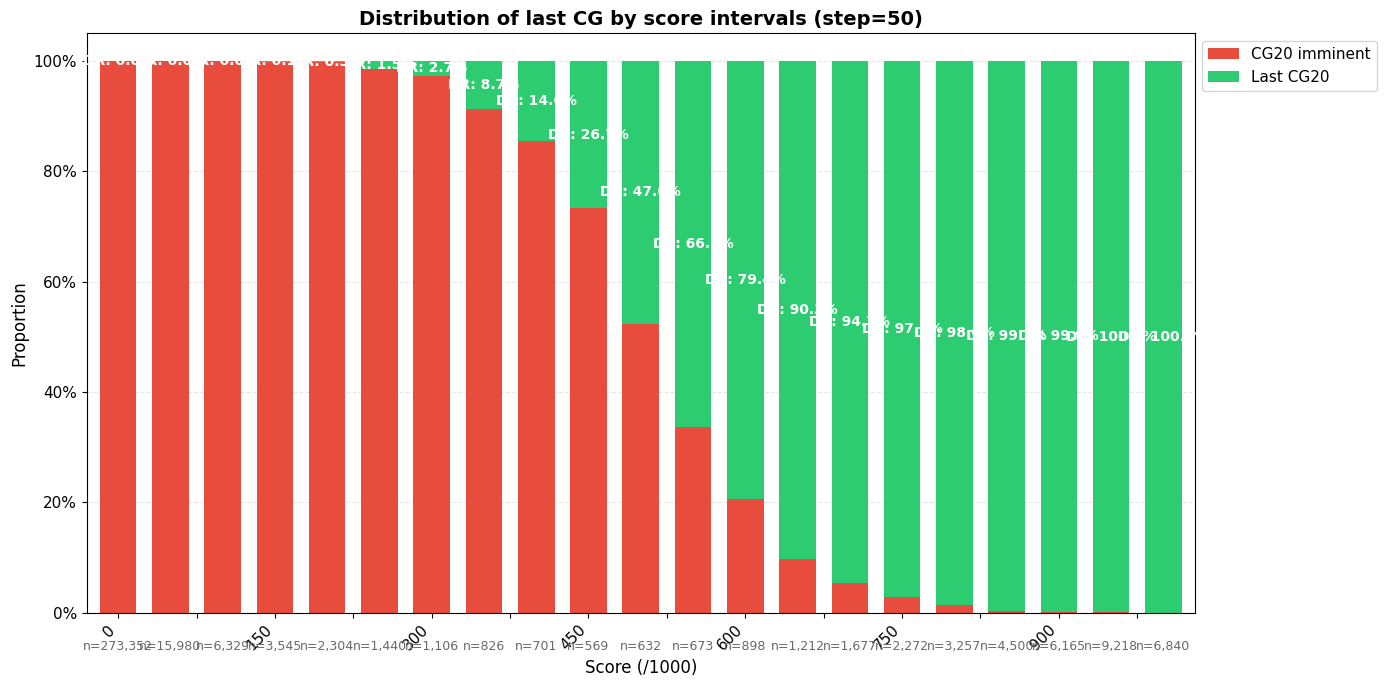


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0 273352       273352        0        0.00%
    50  15980        15979        1        0.01%
   100   6329         6326        3        0.05%
   150   3545         3540        5        0.14%
   200   2304         2298        6        0.26%
   250   1440         1419       21        1.46%
   300   1106         1076       30        2.71%
   350    826          754       72        8.72%
   400    701          599      102       14.55%
   450    569          417      152       26.71%
   500    632          331      301       47.63%
   550    673          227      446       66.27%
   600    898          185      713       79.40%
   650   1212          117     1095       90.35%
   700   1677           89     1588       94.69%
   750   2272           64     2208       97.18%
   800   3257           46     3211       98.59%
   850   4500           14     4486       99.69%
   900   6165            9     6156       

In [38]:
score_graph_empile(train_data, score_col='points', label_col=target_col, pas=50)
#probas_graph_empile(train_data, score_col='points', label_col='default_t_plus_1', pas=0.05)

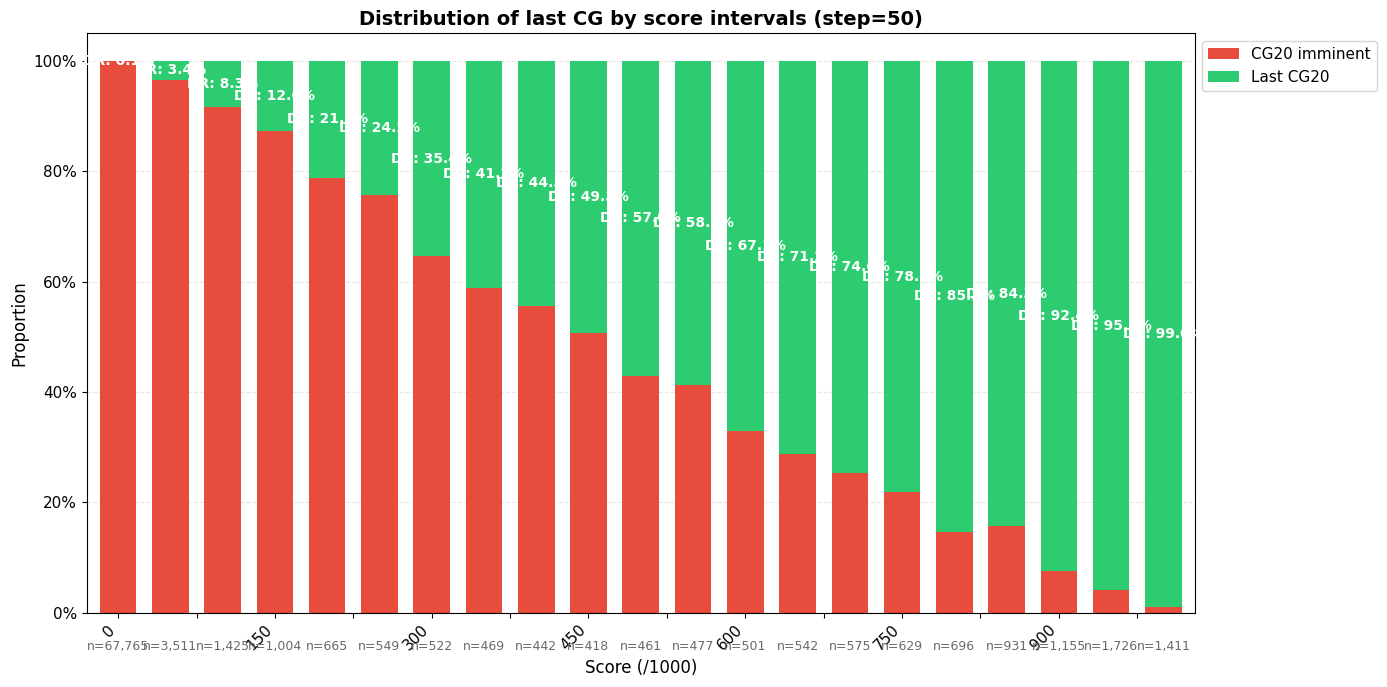


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  67765        67706       59        0.09%
    50   3511         3391      120        3.42%
   100   1425         1307      118        8.28%
   150   1004          877      127       12.65%
   200    665          524      141       21.20%
   250    549          416      133       24.23%
   300    522          337      185       35.44%
   350    469          276      193       41.15%
   400    442          246      196       44.34%
   450    418          212      206       49.28%
   500    461          198      263       57.05%
   550    477          197      280       58.70%
   600    501          165      336       67.07%
   650    542          156      386       71.22%
   700    575          146      429       74.61%
   750    629          137      492       78.22%
   800    696          102      594       85.34%
   850    931          146      785       84.32%
   900   1155           88     1067       

In [39]:
score_graph_empile(test_data, score_col='points', label_col=target_col, pas=50)


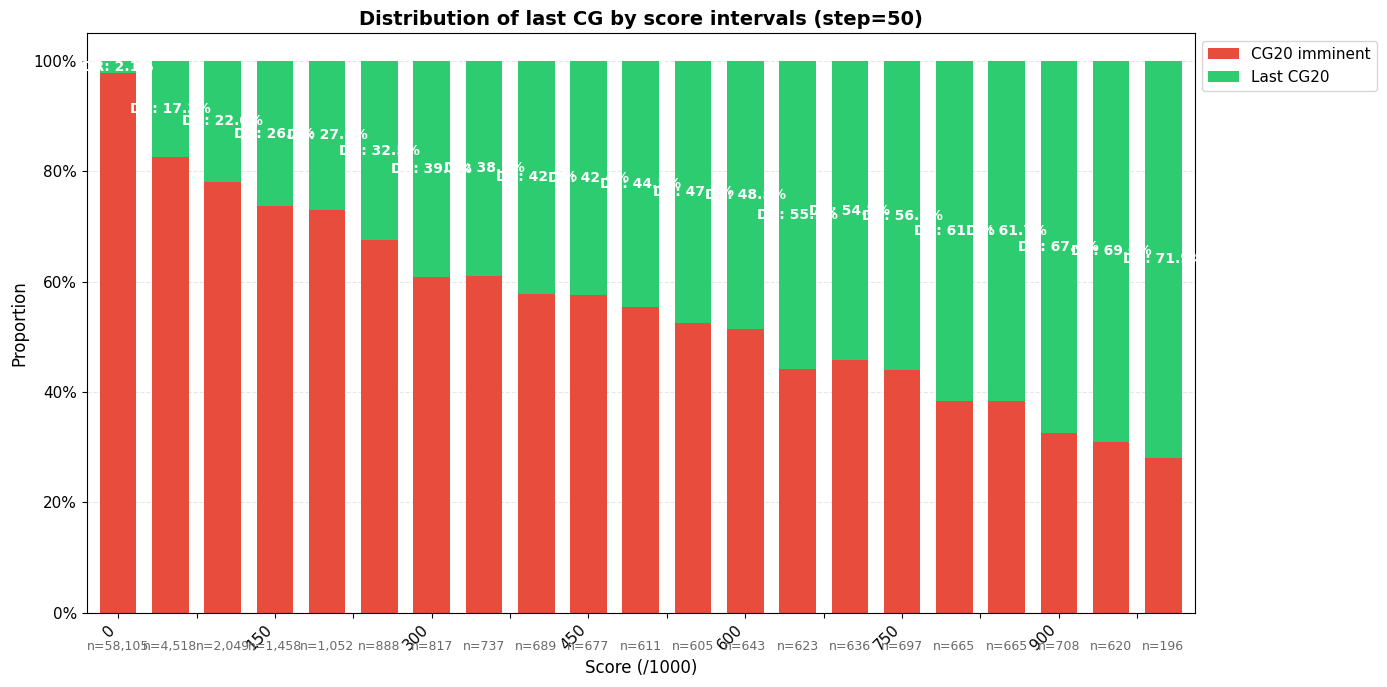


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  58105        56870     1235        2.13%
    50   4518         3735      783       17.33%
   100   2049         1599      450       21.96%
   150   1458         1074      384       26.34%
   200   1052          768      284       27.00%
   250    888          599      289       32.55%
   300    817          497      320       39.17%
   350    737          450      287       38.94%
   400    689          398      291       42.24%
   450    677          390      287       42.39%
   500    611          339      272       44.52%
   550    605          318      287       47.44%
   600    643          331      312       48.52%
   650    623          275      348       55.86%
   700    636          291      345       54.25%
   750    697          306      391       56.10%
   800    665          255      410       61.65%
   850    665          255      410       61.65%
   900    708          231      477       

In [40]:
score_graph_empile(oot_data, score_col='points', label_col=target_col, pas=50)


In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

artefacts = {
    'model'       : model_xgb,
    'vars_to_use' : xgb_vars,
    'best_params' : params,
    'imputer'     : imputer,
    'performance' : {
        'train': {'auc': auc_train, 'gini': gini_train},
        'test' : {'auc': auc_test,  'auc_pr': auc_pr_test, 'rp': rp},
        'oot'  : {'auc': auc_oot,   'auc_pr': auc_pr_oot,  'rp': rp_o},
    },
}

save_path = '../models/xgb_cg30_artefacts.pkl'
joblib.dump(artefacts, save_path)
print(f'Artefacts sauvegardes dans {save_path}')
print(f'  Variables      : {len(xgb_vars)}')
print(f'  Hyperparametres: {list(params.keys())}')
print(f'  ROC AUC train  : {auc_train:.4f}  |  test : {auc_test:.4f}  |  OOT : {auc_oot:.4f}')


Artefacts sauvegardes dans ../models/xgb_cg30_artefacts.pkl
  Variables      : 38
  Hyperparametres: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_alpha', 'reg_lambda']
  Breaks CHR     : [np.float32(5.5597754e-10), np.float32(0.018694442), np.float32(0.063926816), np.float32(0.12897219), np.float32(0.21540937), np.float32(0.32677075), np.float32(0.46399108), np.float32(0.60325533), np.float32(0.7176362), np.float32(0.8076928), np.float32(0.8820847), np.float32(0.94591606), np.float32(0.9997917)]
  ROC AUC train  : 0.9998  |  test : 0.9896  |  OOT : 0.9117
